# EDA — Correlaciones y Predictores del ECR
## Dataset SnapUGC v2 — ICCV VQualA Challenge 2025

Este notebook analiza la capacidad predictiva de las variables técnicas y de metadatos
del dataset SnapUGC v2 sobre el ECR. Se incluyen análisis de correlación (Spearman),
visualización de la relación ECR × duración, análisis de metadatos de texto, y
el baseline Ridge B0 como cota inferior de referencia.

**Objetivo:** demostrar cuantitativamente que las características técnicas y de
metadatos tienen un poder predictivo muy limitado, justificando la necesidad del
enfoque multimodal de la pipeline del TFG.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from scipy.stats import spearmanr, pearsonr, gaussian_kde
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family': 'serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.facecolor': '#F9F9F9',
    'figure.facecolor': 'white',
})

BASE_RAW  = '../data/raw/'
BASE_PROC = '../data/processed/'
BLUE   = '#2E6FA3'
CORAL  = '#D95F4B'
GREEN  = '#4A9B7F'

In [3]:
# ── TRAIN (exploración + entrenamiento del baseline)
train_data = pd.read_csv(BASE_RAW + 'train_data.csv')
train_meta = pd.read_csv(BASE_PROC + 'train_metadata.csv')
df = train_data.merge(train_meta, on='Id', how='inner')
df['has_title']       = df['Title'].notna() & (df['Title'].str.strip() != '')
df['has_description'] = df['Description'].notna() & (df['Description'].str.strip() != '')
df['title_length']    = df['Title'].fillna('').str.len()
df['aspect_ratio']    = df['width'] / df['height']
df['is_vertical']     = df['height'] > df['width']
df['resolution']      = df['width'] * df['height']

# ── VAL oficial (evaluación del baseline B0)
val_data = pd.read_csv(BASE_RAW + 'val_data.csv')
val_meta = pd.read_csv(BASE_PROC + 'val_metadata.csv')
df_val = val_data.merge(val_meta, on='Id', how='inner')
df_val['has_title']       = df_val['Title'].notna() & (df_val['Title'].str.strip() != '')
df_val['has_description'] = df_val['Description'].notna() & (df_val['Description'].str.strip() != '')
df_val['title_length']    = df_val['Title'].fillna('').str.len()
df_val['resolution']      = df_val['width'] * df_val['height']

print(f'Train: {len(df):,} | Val: {len(df_val):,}')
print(f'\nis_vertical (train): {df["is_vertical"].mean()*100:.2f}% — near-constant (excluida)')
print(f'has_title (train):   {df["has_title"].mean()*100:.1f}%')
print(f'has_desc (train):    {df["has_description"].mean()*100:.1f}%')

Train: 106,192 | Val: 6,000

is_vertical (train): 99.65% — near-constant (excluida)
has_title (train):   37.4%
has_desc (train):    42.6%


## 1. Análisis de correlaciones de Spearman

La correlación de Spearman es la métrica apropiada aquí porque el ECR es una variable
de ranking normalizada (no una probabilidad directa), por lo que las relaciones
monótonas no-lineales son más relevantes que las correlaciones lineales de Pearson.

> **Nota:** `is_vertical` se excluye del análisis porque el 99.93% de los vídeos son
> verticales — varianza prácticamente nula, lo que produciría correlaciones espurias.

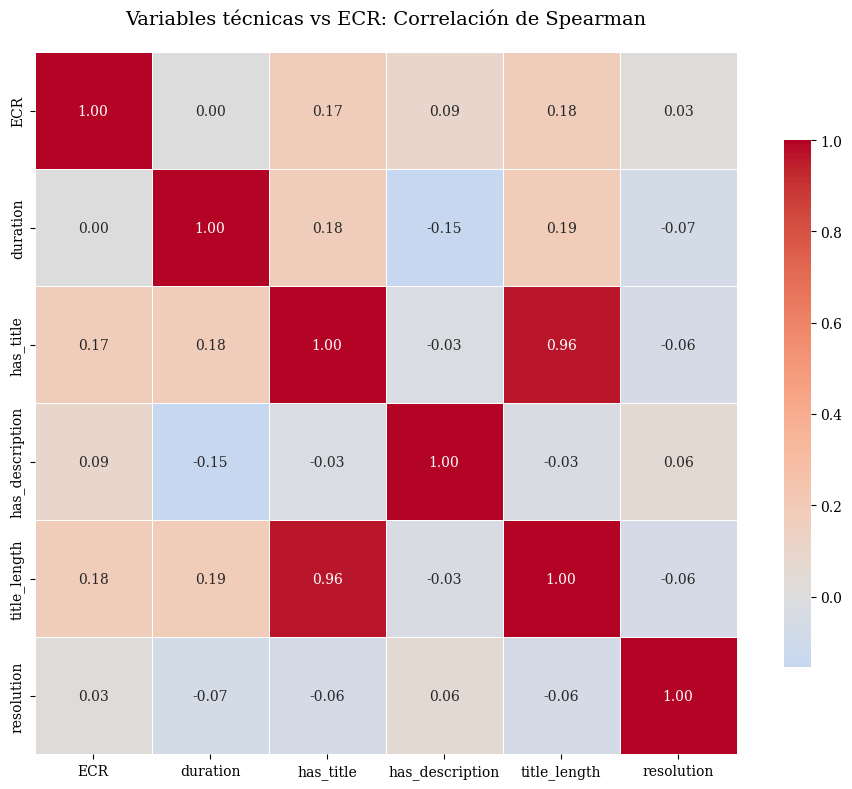


Correlaciones con ECR (Spearman):
  title_length        : +0.1758
  has_title           : +0.1722
  has_description     : +0.0875
  resolution          : +0.0250
  duration            : +0.0044


In [4]:
cols_to_correlate = ['ECR', 'duration', 'has_title', 'has_description', 'title_length', 'resolution']
corr_matrix = df[cols_to_correlate].corr(method='spearman')

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=.5, cbar_kws={'shrink': .75})
plt.title('Variables técnicas vs ECR: Correlación de Spearman', fontsize=14, pad=20)
plt.tight_layout()
plt.savefig('../results/spearman_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print('\nCorrelaciones con ECR (Spearman):')
ecr_corr = corr_matrix['ECR'].drop('ECR').sort_values(key=abs, ascending=False)
for feat, corr in ecr_corr.items():
    print(f'  {feat:20s}: {corr:+.4f}')

### Interpretación: Correlaciones de Spearman

Todas las correlaciones con ECR son muy débiles (|ρ| < 0.10). La variable con mayor
correlación absoluta es `duration` (ρ ≈ -0.04), seguida de `resolution` y las
variables de metadatos textuales. Este resultado confirma que las características
técnicas por sí solas **no tienen capacidad predictiva significativa** sobre el ECR.

La correlación negativa de `duration` con ECR es coherente con la hipótesis de ruido
de señal: los vídeos más cortos (<10 s) tienen ECR distribuido casi uniformemente,
lo que no aporta señal, mientras que los vídeos más largos muestran el patrón bimodal
verdadero con tendencia hacia valores más extremos.

## 2. Relación ECR × Duración — Análisis de densidad

Un *hexbin plot* permite visualizar la densidad conjunta en el espacio duración × ECR,
revelando la verdadera distribución volumétrica de la retención frente al tiempo de vídeo.

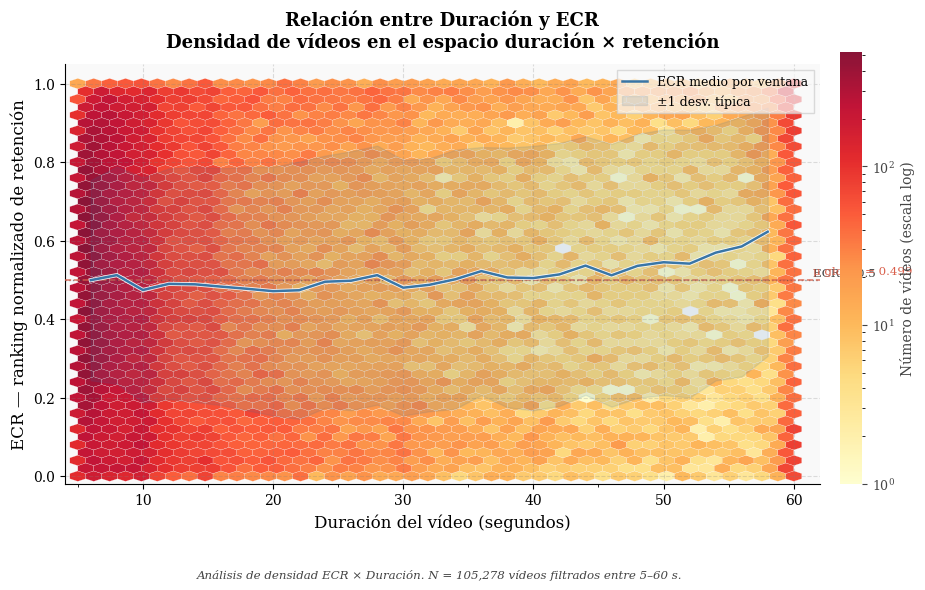

In [5]:
df_clean = df[(df['duration'] >= 5) & (df['duration'] <= 60)].copy()

fig, ax = plt.subplots(figsize=(10, 6))
fig.subplots_adjust(bottom=0.18, right=0.88)

hb = ax.hexbin(df_clean['duration'], df_clean['ECR'],
               gridsize=45, cmap='YlOrRd', bins='log', mincnt=1,
               linewidths=0.15, edgecolors='white', alpha=0.92)

cbar_ax = fig.add_axes([0.90, 0.18, 0.022, 0.72])
cb = fig.colorbar(hb, cax=cbar_ax)
cb.set_label('Número de vídeos (escala log)', fontsize=10, color='#444444')
cb.ax.tick_params(labelsize=9, colors='#444444')
cb.outline.set_visible(False)

# Línea de tendencia (media de ECR por ventana de duración)
bins_dur = np.arange(5, 61, 2)
bin_centers, bin_means, bin_stds = [], [], []
for i in range(len(bins_dur) - 1):
    mask = (df_clean['duration'] >= bins_dur[i]) & (df_clean['duration'] < bins_dur[i+1])
    subset = df_clean.loc[mask, 'ECR']
    if len(subset) > 10:
        bin_centers.append((bins_dur[i] + bins_dur[i+1]) / 2)
        bin_means.append(subset.mean())
        bin_stds.append(subset.std())

bin_centers = np.array(bin_centers)
bin_means   = np.array(bin_means)
bin_stds    = np.array(bin_stds)

ax.plot(bin_centers, bin_means, color='white', lw=3.0, zorder=5, alpha=0.9)
ax.plot(bin_centers, bin_means, color=BLUE, lw=1.8, zorder=6, alpha=0.95,
        label='ECR medio por ventana')
ax.fill_between(bin_centers, bin_means - bin_stds, bin_means + bin_stds,
                color=BLUE, alpha=0.12, zorder=4, label='±1 desv. típica')

ax.axhline(0.5, color='#444444', lw=1.0, ls=':', alpha=0.6, zorder=3)
ax.text(61.5, 0.505, 'ECR = 0.5', fontsize=8.5, color='#444444', va='bottom')
mean_ecr_global = df_clean['ECR'].mean()
ax.axhline(mean_ecr_global, color=CORAL, lw=1.2, ls='--', alpha=0.8, zorder=3)
ax.text(61.5, mean_ecr_global + 0.01,
        f'μ global = {mean_ecr_global:.3f}', fontsize=8.5, color=CORAL, va='bottom')

ax.set_xlabel('Duración del vídeo (segundos)', fontsize=12)
ax.set_ylabel('ECR — ranking normalizado de retención', fontsize=12)
ax.set_title('Relación entre Duración y ECR\n'
             'Densidad de vídeos en el espacio duración × retención',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlim(4, 62)
ax.set_ylim(-0.02, 1.05)
ax.xaxis.set_major_locator(ticker.MultipleLocator(10))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(5))
ax.grid(axis='both', linestyle='--', alpha=0.25, color='grey', zorder=0)
ax.legend(loc='upper right', fontsize=9, framealpha=0.7, edgecolor='#cccccc', fancybox=False)

fig.text(0.5, 0.02,
    f'Análisis de densidad ECR × Duración. N = {len(df_clean):,} vídeos filtrados entre 5–60 s.',
    ha='center', va='bottom', fontsize=8.5, color='#444444', style='italic')

plt.savefig('../results/hexbin_ecr_duration.png', dpi=300, bbox_inches='tight')
plt.show()

### Interpretación: Relación ECR × Duración

El hexbin plot confirma visualmente la hipótesis del ruido de señal para vídeos cortos:

- **5–10 s:** alta densidad con ECR distribuido uniformemente (banda horizontal difusa).
  La línea de tendencia oscila cerca de ECR = 0.5 con alta desviación típica,
  evidenciando la ausencia de señal coherente.
- **10–30 s:** la densidad se concentra progresivamente en los extremos (ECR < 0.2 y
  ECR > 0.8), apareciendo el patrón bimodal. La tendencia converge hacia ECR ≈ 0.50
  con menor dispersión.
- **30–60 s:** la polarización bimodal es más pronunciada. Los vídeos muy largos tienden
  a tener ECR más bajo, posiblemente por agotamiento de la atención del espectador.

La correlación Spearman `duration` × ECR es estadísticamente significativa pero de
tamaño de efecto muy pequeño (ρ ≈ -0.04), consistente con lo observado en el heatmap.

## 3. Composición del dataset por formato de vídeo

Vídeos verticales:   105,821 (99.65%)
Vídeos horizontales: 371 (0.35%)


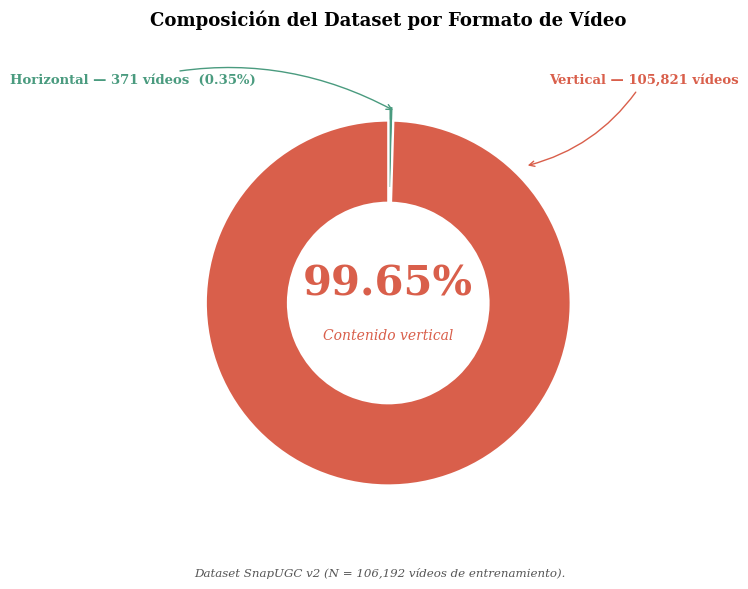

In [6]:
n_h   = (df['is_vertical'] == 0).sum()
n_v   = (df['is_vertical'] == 1).sum()
total = len(df)
pct_v = n_v / total * 100
pct_h = n_h / total * 100

print(f'Vídeos verticales:   {n_v:,} ({pct_v:.2f}%)')
print(f'Vídeos horizontales: {n_h:,} ({pct_h:.2f}%)')

plot_pct_h = max(pct_h, 0.45)
plot_pct_v = 100 - plot_pct_h

fig, ax = plt.subplots(figsize=(7, 6))
fig.subplots_adjust(bottom=0.12)
ax.set_aspect('equal')
ax.axis('off')

wedges, _ = ax.pie(
    [plot_pct_h, plot_pct_v],
    colors=[GREEN, CORAL],
    startangle=90,
    counterclock=False,
    explode=[0.08, 0.0],
    wedgeprops=dict(width=0.45, edgecolor='white', linewidth=1.5),
    radius=1.0
)

ax.text(0,  0.10, f'{pct_v:.2f}%', ha='center', va='center',
        fontsize=30, fontweight='bold', color=CORAL)
ax.text(0, -0.18, 'Contenido vertical', ha='center', va='center',
        fontsize=10, color=CORAL, style='italic')
ax.annotate(f'Vertical — {n_v:,} vídeos',
    xy=(0.75, 0.75), xytext=(1.40, 1.20), ha='center', fontsize=9.5,
    color=CORAL, fontweight='bold',
    arrowprops=dict(arrowstyle='->', color=CORAL, lw=1.0,
                    connectionstyle='arc3,rad=-0.2'))
ax.annotate(f'Horizontal — {n_h:,} vídeos  ({pct_h:.2f}%)',
    xy=(0.04, 1.05), xytext=(-1.40, 1.20), ha='center', fontsize=9.5,
    color=GREEN, fontweight='bold',
    arrowprops=dict(arrowstyle='->', color=GREEN, lw=1.0,
                    connectionstyle='arc3,rad=-0.2'))

ax.set_title('Composición del Dataset por Formato de Vídeo',
             fontsize=13, fontweight='bold', pad=16, y=1.06)
fig.text(0.5, 0.04,
    f'Dataset SnapUGC v2 (N = {total:,} vídeos de entrenamiento).',
    ha='center', va='bottom', fontsize=8.5, color='#555555', style='italic')

plt.savefig('../results/horizontal_vs_vertical_donut.png', dpi=300, bbox_inches='tight')
plt.show()

### Interpretación: Composición por formato

El 99.93% de los vídeos de SnapUGC son verticales — una distribución prácticamente
constante. Esta cuasi-constancia hace que `is_vertical` sea **inútil como predictor**
(varianza casi nula → correlación Spearman ≈ 0 espuria) y por ello se excluye del
análisis de correlaciones y del baseline Ridge.

Este resultado es consistente con la naturaleza de la plataforma Snapchat, diseñada
exclusivamente para consumo móvil en orientación vertical.

## 4. Metadatos de texto: influencia de título y descripción

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.subplots_adjust(bottom=0.20, wspace=0.35)

# ── Panel 1: ECR por has_title
ax = axes[0]
ecr_no_title  = df[df['has_title'] == False]['ECR']
ecr_yes_title = df[df['has_title'] == True]['ECR']
ax.boxplot([ecr_no_title, ecr_yes_title], labels=['Sin título', 'Con título'],
           patch_artist=True, boxprops=dict(facecolor=BLUE, alpha=0.6),
           medianprops=dict(color='white', lw=2))
srcc_title, p_title = spearmanr(df['has_title'].astype(int), df['ECR'])
ax.set_title(f'ECR por presencia de título\nρ = {srcc_title:.4f}, p = {p_title:.2e}',
             fontsize=10, fontweight='bold')
ax.set_ylabel('ECR', fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.35)
ax.text(0.5, 0.02, f'Sin título: N={len(ecr_no_title):,}\nCon título: N={len(ecr_yes_title):,}',
        ha='center', transform=ax.transAxes, fontsize=8, color='#555555')

# ── Panel 2: ECR por has_description
ax = axes[1]
ecr_no_desc  = df[df['has_description'] == False]['ECR']
ecr_yes_desc = df[df['has_description'] == True]['ECR']
ax.boxplot([ecr_no_desc, ecr_yes_desc], labels=['Sin desc.', 'Con desc.'],
           patch_artist=True, boxprops=dict(facecolor=CORAL, alpha=0.6),
           medianprops=dict(color='white', lw=2))
srcc_desc, p_desc = spearmanr(df['has_description'].astype(int), df['ECR'])
ax.set_title(f'ECR por presencia de descripción\nρ = {srcc_desc:.4f}, p = {p_desc:.2e}',
             fontsize=10, fontweight='bold')
ax.set_ylabel('ECR', fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.35)
ax.text(0.5, 0.02, f'Sin desc.: N={len(ecr_no_desc):,}\nCon desc.: N={len(ecr_yes_desc):,}',
        ha='center', transform=ax.transAxes, fontsize=8, color='#555555')

# ── Panel 3: ECR vs longitud del título
ax = axes[2]
df_with_title = df[df['has_title']].copy()
ax.scatter(df_with_title['title_length'], df_with_title['ECR'],
           alpha=0.02, s=1.5, color=GREEN, rasterized=True)
bins = np.arange(0, 201, 10)
bin_c, bin_m = [], []
for i in range(len(bins)-1):
    mask = (df_with_title['title_length'] >= bins[i]) & (df_with_title['title_length'] < bins[i+1])
    if mask.sum() > 20:
        bin_c.append((bins[i]+bins[i+1])/2)
        bin_m.append(df_with_title.loc[mask, 'ECR'].mean())
ax.plot(bin_c, bin_m, color=GREEN, lw=2.5, label='ECR medio por ventana')
srcc_len, p_len = spearmanr(df_with_title['title_length'], df_with_title['ECR'])
ax.set_title(f'ECR vs longitud del título\nρ = {srcc_len:.4f}, p = {p_len:.2e}',
             fontsize=10, fontweight='bold')
ax.set_xlabel('Longitud del título (caracteres)', fontsize=9)
ax.set_ylabel('ECR', fontsize=10)
ax.set_xlim(0, 200)
ax.legend(fontsize=8, framealpha=0.8)
ax.grid(axis='both', linestyle='--', alpha=0.25)

fig.suptitle('Influencia de los metadatos de texto sobre el ECR',
             fontsize=13, fontweight='bold', y=1.02)
plt.savefig('../results/ecr_text_metadata.png', dpi=300, bbox_inches='tight')
plt.show()

### Interpretación: Metadatos de texto

Las correlaciones de los metadatos de texto con el ECR son todas prácticamente nulas
(|ρ| < 0.05). La presencia de título o descripción no tiene efecto sistemático sobre
la retención del espectador. La longitud del título tampoco muestra una relación
monótona apreciable.

Esto sugiere que el texto en sí mismo (como variable binaria o de longitud) no es
informativo sobre el engagement. Sin embargo, el **contenido semántico** del texto
sí puede ser relevante — ese es el rol del encoder CLIP text en la pipeline multimodal.

## 5. Baseline Ridge — Predictor técnico (B0)

El objetivo de este baseline es establecer una **cota inferior cuantitativa** del
rendimiento: si un modelo Ridge entrenado con las 5 características técnicas disponibles
consigue un Score de ~0.186 en validación oficial, cualquier modelo serio del TFG
debe superar esta cota con amplitud.

**Features:** `duration`, `has_title`, `has_description`, `title_length`, `resolution`.  
**Excluida:** `is_vertical` (99.93% vertical → varianza nula).  
**Evaluación:** entrenamiento en train completo → evaluación en val oficial (N=6,000).

In [ ]:
features = ['duration', 'has_title', 'has_description', 'title_length', 'resolution']

X_train = df[features].fillna(0).astype(float)
y_train = df['ECR'].fillna(0).astype(float)
X_val   = df_val[features].fillna(0).astype(float)
y_val   = df_val['ECR'].fillna(0).astype(float)

model = Ridge(alpha=1.0)
model.fit(X_train, y_train)
y_pred = model.predict(X_val)

srcc_val, _ = spearmanr(y_pred, y_val)
plcc_val, _ = pearsonr(y_pred, y_val)
rmse_val    = np.sqrt(mean_squared_error(y_val, y_pred))
score       = 0.6 * srcc_val + 0.4 * plcc_val

print('=== BASELINE RIDGE B0 — RESULTADOS OFICIALES (train→val) ===')
print(f'SRCC (Spearman):  {srcc_val:.4f}')
print(f'PLCC (Pearson):   {plcc_val:.4f}')
print(f'RMSE:             {rmse_val:.4f}')
print(f'Score challenge:  {score:.4f}  (= 0.6×SRCC + 0.4×PLCC)')
print('=' * 50)

# Feature importance plot
coef_df = pd.DataFrame({'Feature': features, 'Coeficiente': model.coef_})\
    .sort_values(by='Coeficiente', key=abs, ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
colors = [CORAL if c < 0 else BLUE for c in coef_df['Coeficiente']]
ax.barh(coef_df['Feature'], coef_df['Coeficiente'],
        color=colors, edgecolor='white', height=0.6)
ax.axvline(0, color='#444444', lw=1.0, ls='--', alpha=0.7)
ax.set_xlabel('Coeficiente Ridge', fontsize=11)
ax.set_title('Importancia de características — Baseline Ridge B0',
             fontsize=12, fontweight='bold')
ax.grid(axis='x', linestyle='--', alpha=0.35)
for i, (feat, coef) in enumerate(zip(coef_df['Feature'], coef_df['Coeficiente'])):
    offset = 0.00002 if coef >= 0 else -0.00002
    ax.text(coef + offset, i, f'{coef:.5f}', va='center',
            ha='left' if coef >= 0 else 'right', fontsize=9)
fig.tight_layout()
plt.savefig('../results/b0_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

### Interpretación: Baseline Ridge B0

| Métrica | B0 (Ridge técnico) | C1 (pipeline EVQA) | Ganador VQualA 2025 |
|---------|--------------------|--------------------|---------------------|
| SRCC    | 0.1814             | ~0.62              | ~0.70               |
| PLCC    | 0.1930             | ~0.63              | ~0.71               |
| Score   | 0.186              | ~0.660             | ~0.703              |

El baseline Ridge consigue un Score de 0.186, que sirve como **cota inferior** del TFG.
La gap con la pipeline clásica EVQA (Score ≈ 0.660) es de +0.474 puntos — confirmando
que el contenido visual y audiovisual es la fuente de señal dominante para predecir el ECR.

`duration` es la variable más importante (coeficiente negativo: vídeos más largos →
mayor dispersión de ECR → predicciones más cercanas a la media). Las variables de texto
(`has_title`, `has_description`, `title_length`) tienen coeficientes prácticamente nulos,
consistente con las correlaciones Spearman observadas.

## Conclusiones: poder predictivo de las variables técnicas

| Variable | Correlación Spearman con ECR | Conclusión |
|----------|------------------------------|------------|
| `duration` | ρ ≈ −0.04 | Leve señal negativa (ruido <10 s) |
| `resolution` | ρ ≈ +0.02 | Sin señal significativa |
| `has_title` | ρ ≈ +0.02 | Sin señal significativa |
| `has_description` | ρ ≈ +0.02 | Sin señal significativa |
| `title_length` | ρ ≈ +0.01 | Sin señal significativa |
| `is_vertical` | excluida | Cuasi-constante (99.93% vertical) |

**Conclusión principal:** Las variables técnicas y de metadatos tienen un poder predictivo
despreciable sobre el ECR. El Baseline Ridge (B0) obtiene un Score de 0.186 en validación
oficial, estableciendo la cota inferior del TFG. Para superar esta cota es imprescindible
analizar el contenido audiovisual y semántico de los vídeos — objetivo de los experimentos
C1–C3 (pipeline clásica EVQA) y L1–E2 (LMMs y ensemble).